Device    : cuda:1
Baselines : ['ATC', 'ATC-NE', 'AC', 'DOC', 'COT']
P_LOW=0.001, P_HIGH=0.999

LOADING TRAINING DATA
Train scores shape: (3394245, 5)
  Class 0: 1000000 samples
  Class 1: 1000000 samples
  Class 2: 776366 samples
  Class 3: 568007 samples
  Class 4: 49872 samples

FLOW MODEL
✓ ScoreShiftFlowWrapper defined
  feature_dim=64  score_dim=5  n_flows=12
  FeatureClipper: p_low=0.001, p_high=0.999
✓ Flow loaded from BCSS/bcss_score_shift_flow_new.pth

FITTING FEATURE CLIPPER

[CLIPPER] Fitting on train features...
  Raw train features: min=-87.5564  max=77.8628  std=1.7335  shape=(3394245, 64)
✓ FeatureClipper fitted  (p_low=0.001, p_high=0.999):
  lo : min=-27.3709  max=-0.5825
  hi : min=0.6474  max=31.2569
  train clip fraction: 0.200%  ← должно быть мало
✓ FeatureClipper saved to BCSS/feature_clipper.pth

ДИАГНОСТИКА
Тайл: TCGA-EW-A3U0-DX1_xmin113512_ymin48566_MPP-0.2500.png.tensor

[PRE-CHECK] Статистика test features (до клипирования):
  shape  : (4096, 64)
  min    : 

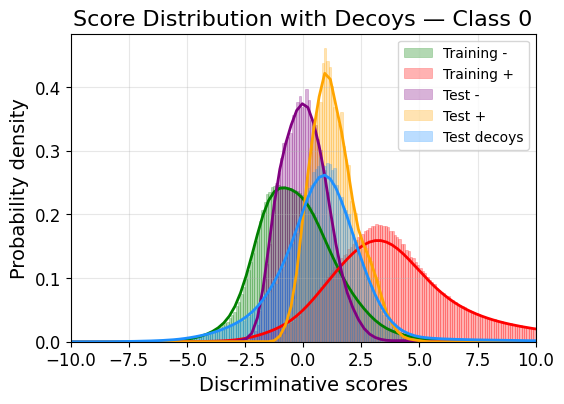

<Figure size 640x480 with 0 Axes>

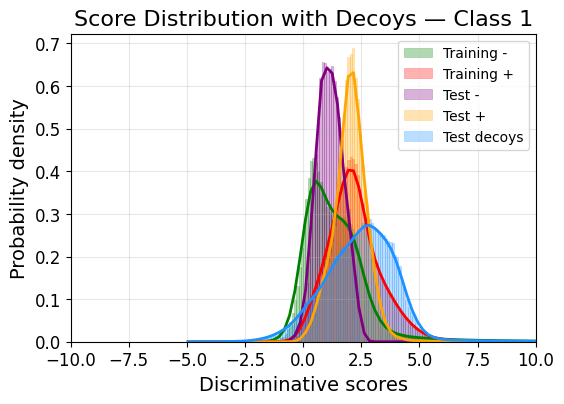

/home/arina/.conda/envs/breeds/lib/python3.9/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


<Figure size 640x480 with 0 Axes>

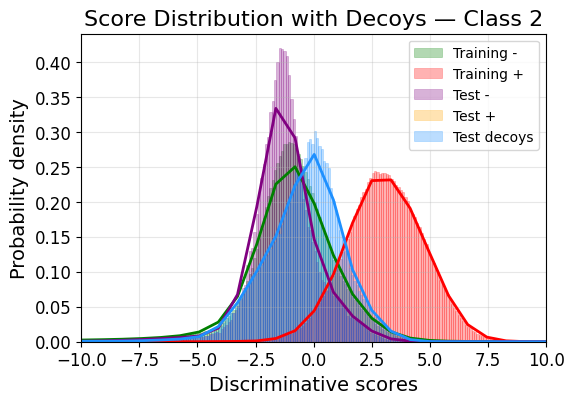

<Figure size 640x480 with 0 Axes>

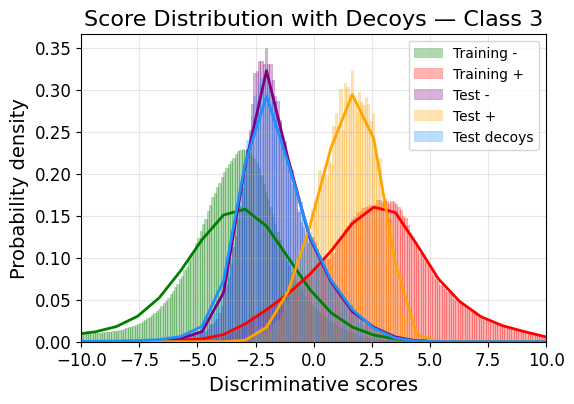

<Figure size 640x480 with 0 Axes>

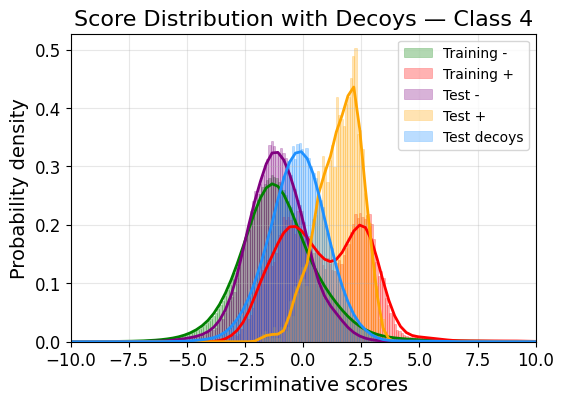

✓ Score distributions сохранены для 5 классов

FDR ANALYSIS
  accuracy : 0.6954
  error/pi0: 0.3046


<Figure size 640x480 with 0 Axes>

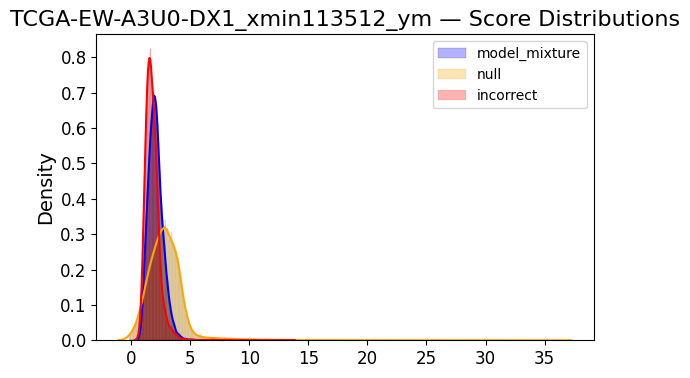

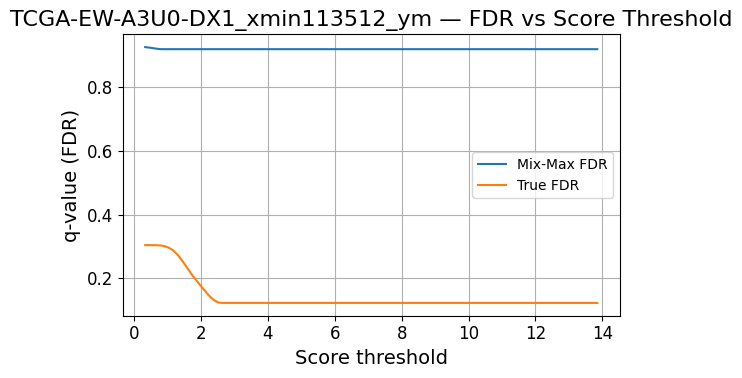

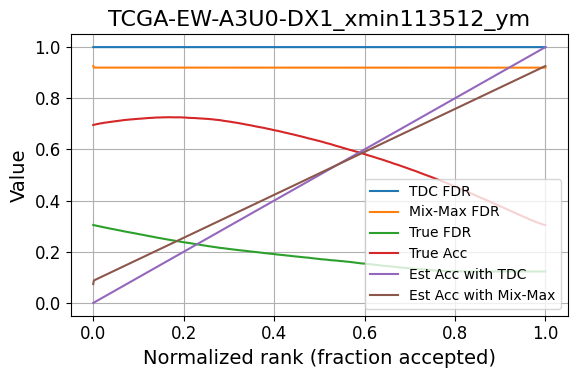


                                   ACC_ST      ACC_TA
  ────────────────────────────────────────────────────
  True                             0.6954      0.7261
  TDC  (est | err)             0.0000  +0.6954  1.0000  +0.2739
  Mix-Max (est | err)          0.0738  +0.6216  0.9262  +0.2001

✅ Pipeline complete!


In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import glob
import seaborn as sns

from data_processing.score_feature_dataset import (
    ScoreFeatureDataset,
    create_score_feature_dataset_bcss,
)
from data_processing.negative_scores_pool import collect_negative_scores
from utils.other_methods import *
from utils.visualize_distributions import *
from fdr.fdr_control import *
from fdr.plot_fdr import *


import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm


# ═════════════════════════════════════════════════════════════════════════════
# FeatureClipper — клипирование outliers по train-статистике
# ═════════════════════════════════════════════════════════════════════════════

class FeatureClipper:
    def __init__(self, p_low=0.001, p_high=0.999):
        self.p_low   = p_low
        self.p_high  = p_high
        self.lo      = None
        self.hi      = None
        self.fitted  = False

    def fit(self, features):
        features = features.float()
        self.lo  = torch.quantile(features, self.p_low,  dim=0, keepdim=True)
        self.hi  = torch.quantile(features, self.p_high, dim=0, keepdim=True)
        self.fitted = True
        return self

    def transform(self, features):
        if not self.fitted:
            raise ValueError("FeatureClipper не обучен!")
        device = features.device
        lo = self.lo.to(device)
        hi = self.hi.to(device)
        features_f = features.float()
        clipped_frac = ((features_f < lo) | (features_f > hi)).float().mean().item()
        clipped = features_f.clamp(min=lo, max=hi)
        return clipped, clipped_frac

    def fit_transform(self, features):
        self.fit(features)
        return self.transform(features)

    def save(self, path):
        torch.save({'lo': self.lo, 'hi': self.hi, 
                    'p_low': self.p_low, 'p_high': self.p_high}, path)

    def load(self, path):
        data = torch.load(path, map_location='cpu', weights_only=True)
        self.lo      = data['lo']
        self.hi      = data['hi']
        self.p_low   = data.get('p_low',  0.001)
        self.p_high  = data.get('p_high', 0.999)
        self.fitted  = True
        return self


# ═════════════════════════════════════════════════════════════════════════════
# Building blocks
# ═════════════════════════════════════════════════════════════════════════════

class ActNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim       = dim
        self.log_scale = nn.Parameter(torch.zeros(dim))
        self.bias      = nn.Parameter(torch.zeros(dim))
        self.register_buffer('initialized', torch.tensor(False))

    def forward(self, x, reverse=False):
        if not self.initialized and not reverse:
            with torch.no_grad():
                self.bias.data      = -x.mean(0)
                self.log_scale.data = -x.std(0).clamp(min=1e-6).log()
            self.initialized.fill_(True)

        if not reverse:
            y       = (x + self.bias) * self.log_scale.exp()
            log_det = self.log_scale.sum().expand(x.size(0))
            return y, log_det
        else:
            x_rec   = x * (-self.log_scale).exp() - self.bias
            log_det = -self.log_scale.sum().expand(x.size(0))
            return x_rec, log_det

class CouplingLayer(nn.Module):
    def __init__(self, dim, feature_dim, hidden_dim=256, mask_type='first_half'):
        super().__init__()
        self.mask_type = mask_type
        self.d_in  = dim // 2 if mask_type == 'first_half' else dim - dim // 2
        self.d_out = dim - dim // 2 if mask_type == 'first_half' else dim // 2

        self.net = nn.Sequential(
            nn.Linear(self.d_in + feature_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.GELU(),
        )
        self.scale_head = nn.Sequential(nn.Linear(hidden_dim // 2, self.d_out), nn.Tanh())
        self.translate_head = nn.Linear(hidden_dim // 2, self.d_out)
        nn.init.zeros_(self.scale_head[0].weight)
        nn.init.zeros_(self.scale_head[0].bias)
        nn.init.zeros_(self.translate_head.weight)
        nn.init.zeros_(self.translate_head.bias)

    def _split(self, x):
        if self.mask_type == 'first_half': return x[:, :self.d_in], x[:, self.d_in:]
        return x[:, self.d_out:], x[:, :self.d_out]

    def _merge(self, x1, x2):
        if self.mask_type == 'first_half': return torch.cat([x1, x2], dim=1)
        return torch.cat([x2, x1], dim=1)

    def forward(self, x, features, reverse=False):
        x1, x2     = self._split(x)
        h          = self.net(torch.cat([x1, features], dim=1))
        s, t       = self.scale_head(h), self.translate_head(h)
        if not reverse:
            return self._merge(x1, x2 * torch.exp(s) + t), s.sum(dim=1)
        return self._merge(x1, (x2 - t) * torch.exp(-s)), -s.sum(dim=1)


class ScoreShiftFlow(nn.Module):
    def __init__(self, score_dim=10, feature_dim=640, n_flows=12, hidden_dim=256, encoder_dim=128):
        super().__init__()
        self.score_dim = score_dim
        self._log_2pi  = float(np.log(2 * np.pi))
        self.feature_encoder = nn.Sequential(
            nn.Linear(feature_dim, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, encoder_dim), nn.LayerNorm(encoder_dim), nn.GELU(),
        )
        self.layers = nn.ModuleList()
        for i in range(n_flows):
            self.layers.append(CouplingLayer(
                score_dim, encoder_dim, hidden_dim, 'first_half' if i % 2 == 0 else 'second_half'))
            if i < n_flows - 1: self.layers.append(ActNorm(score_dim))

    def encode(self, features): return self.feature_encoder(features)

    def forward(self, scores, features, reverse=False):
        enc, log_det_sum = self.encode(features), torch.zeros(scores.size(0), device=scores.device)
        x = scores
        for layer in (reversed(self.layers) if reverse else self.layers):
            x, ld = layer(x, reverse=reverse) if isinstance(layer, ActNorm) else layer(x, enc, reverse=reverse)
            log_det_sum += ld
        return x, log_det_sum

    def log_prob(self, scores, features):
        z, log_det = self.forward(scores, features, reverse=False)
        return -0.5 * (z ** 2).sum(dim=1) - 0.5 * self.score_dim * self._log_2pi + log_det

    def sample(self, features):
        z = torch.randn(features.size(0), self.score_dim, device=features.device)
        scores, _ = self.forward(z, features, reverse=True)
        return scores


class ScoreShiftFlowWrapper(nn.Module):
    def __init__(self, num_classes=10, n_flows=12, feature_dim=640, hidden_dim=256, encoder_dim=128, p_low=0.001, p_high=0.999):
        super().__init__()
        self.flow = ScoreShiftFlow(num_classes, feature_dim, n_flows, hidden_dim, encoder_dim)
        self.feature_clipper = FeatureClipper(p_low=p_low, p_high=p_high)

    def fit_feature_clipper(self, score_dataset):
        loader = DataLoader(score_dataset, batch_size=2048, shuffle=False)
        all_features = torch.cat([f for _, f, _, _ in loader], dim=0)
        self.feature_clipper.fit(all_features)
        return self

    def _clip_features(self, features):
        if self.feature_clipper.fitted:
            clipped, _ = self.feature_clipper.transform(features)
            return clipped
        return features.float()

    def generate_decoys(self, score_dataset, device='cuda', n_samples=1, clip=True):
        self.flow.to(device).eval()
        cnn_list, decoy_list, lbl_list = [], [], []
        loader = DataLoader(score_dataset, batch_size=256, shuffle=False)
        with torch.no_grad():
            for cnn_scores, features, _, labels in loader:
                features = features.to(device)
                if clip: features = self._clip_features(features)
                decoy = self.flow.sample(features) if n_samples == 1 else torch.stack([self.flow.sample(features) for _ in range(n_samples)]).mean(dim=0)
                cnn_list.append(cnn_scores.cpu().numpy())
                decoy_list.append(decoy.cpu().numpy())
                lbl_list.append(labels.cpu().numpy())
        return np.concatenate(cnn_list), np.concatenate(decoy_list), np.concatenate(lbl_list)


# ═════════════════════════════════════════════════════════════════════════════
# Helpers & Calibration
# ═════════════════════════════════════════════════════════════════════════════

def get_scores_from_ds(dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    cnn_list, lbl_list = [], []
    with torch.no_grad():
        for cnn_scores, _, _, labels in loader:
            cnn_list.append(cnn_scores.cpu().numpy())
            lbl_list.append(labels.cpu().numpy())
    return np.concatenate(cnn_list), np.concatenate(lbl_list)

def load_bcss_test_file(fpath):
    data = torch.load(fpath, weights_only=False)
    predictions = torch.flatten(data['predictions'], start_dim=2).squeeze(0).T
    features    = torch.flatten(data['features'],    start_dim=2).squeeze(0).T
    labels      = torch.flatten(torch.tensor(data['mask']), start_dim=0)
    labels      = torch.where(labels <= 3, labels, torch.tensor(4))
    return ScoreFeatureDataset(predictions, features, predictions, labels)

def align_decoys(pred_scores, decoy_scores):
    """
    Калибрует decoy_scores так, чтобы их распределение совпадало
    с левым хвостом (неправильными предсказаниями) pred_scores.
    """
    m_pred = np.median(pred_scores)
    m_decoy = np.median(decoy_scores)
    
    left_pred = pred_scores[pred_scores < m_pred]
    left_decoy = decoy_scores[decoy_scores < m_decoy]
    
    if len(left_pred) > 10 and len(left_decoy) > 10:
        std_p, std_d = np.std(left_pred), np.std(left_decoy)
        if std_d > 1e-6:
            scale = std_p / std_d
            shift = np.mean(left_pred) - np.mean(left_decoy) * scale
            print(f"[CALIBRATION] Decoys scaled by {scale:.3f} and shifted by {shift:.3f}")
            return decoy_scores * scale + shift
    return decoy_scores


# ═════════════════════════════════════════════════════════════════════════════
# Config
# ═════════════════════════════════════════════════════════════════════════════

DEVICE          = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES     = 5
FEATURE_DIM     = 64
PATH_DATA       = '../../data/BCSS/training/bcss.mini.training.torch'
TEST_FOLDER     = '../../data/BCSS/test/'
FLOWS_PATH      = 'BCSS/bcss_score_shift_flow_new.pth'
CLIPPER_PATH    = 'BCSS/feature_clipper.pth'
SUBSAMPLE_STEP  = 10

P_LOW, P_HIGH = 0.001, 0.999

os.makedirs('BCSS/figures/accuracy', exist_ok=True)
os.makedirs('BCSS/figures/diagnostics', exist_ok=True)


# ═════════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ═════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("LOADING DATA AND FLOW")
print("="*70)

data     = torch.load(PATH_DATA, weights_only=False)
train_ds = create_score_feature_dataset_bcss(data, DEVICE)
train_scores, train_labels = get_scores_from_ds(train_ds)

flow = ScoreShiftFlowWrapper(
    num_classes=NUM_CLASSES, feature_dim=FEATURE_DIM, 
    p_low=P_LOW, p_high=P_HIGH
).to(DEVICE)

if os.path.exists(FLOWS_PATH):
    flow.load_state_dict(torch.load(FLOWS_PATH, map_location=DEVICE, weights_only=False))
if os.path.exists(CLIPPER_PATH):
    flow.feature_clipper.load(CLIPPER_PATH)
else:
    flow.fit_feature_clipper(train_ds)
    flow.feature_clipper.save(CLIPPER_PATH)

first_tile = TEST_FOLDER + 'TCGA-EW-A3U0-DX1_xmin113512_ymin48566_MPP-0.2500.png.tensor'
tile_name  = os.path.basename(first_tile)
test_ds    = load_bcss_test_file(first_tile)


print("\n" + "="*70)
print("GENERATING & CALIBRATING DECOYS")
print("="*70)

ms, ds_flow, ls = flow.generate_decoys(test_ds, device=DEVICE, clip=True)

# Subsample
ms      = ms[::SUBSAMPLE_STEP]
ds_flow = ds_flow[::SUBSAMPLE_STEP]
ls      = ls[::SUBSAMPLE_STEP]
n_samples = len(ls)

pred_scores  = np.max(ms, axis=1)
pred_label   = np.argmax(ms, axis=1)
decoy_scores = np.max(ds_flow, axis=1)
correct_pred = (ls == pred_label).astype(int)

# ── Ключевой шаг: Калибровка decoy_scores ─────────────────────────────────────
decoy_scores = align_decoys(pred_scores, decoy_scores)


# ═════════════════════════════════════════════════════════════════════════════
# FDR ANALYSIS
# ═════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("FDR ANALYSIS")
print("="*70)

print(f"  True Accuracy : {correct_pred.mean():.4f}")
print(f"  True Pi0      : {1 - correct_pred.mean():.4f}")

# ── Figure 1: Score distributions ─────────────────────────────────────────────
bin_width  = 0.05
bins       = np.arange(pred_scores.min() - 0.5, pred_scores.max() + 0.5, bin_width)

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(pred_scores, bins=bins, stat='density', color='blue', alpha=0.3, label='Pred Scores', ax=ax)
sns.histplot(decoy_scores, bins=bins, stat='density', color='orange', alpha=0.3, label='Decoy Scores (Aligned)', ax=ax)
sns.histplot(pred_scores[ls != pred_label], bins=bins, stat='density', color='red', alpha=0.3, label='Incorrect Preds', ax=ax)
ax.set_title(f'Score Distributions (Aligned)')
ax.legend()
plt.tight_layout()
safe_name = 'shift_flow_' + tile_name.replace('.tensor', '')
plt.savefig(f'BCSS/figures/diagnostics/{safe_name}_scores.png', dpi=150)
plt.show()

# ── True FDR ──────────────────────────────────────────────────────────────────
sort_idx           = np.argsort(pred_scores)
pred_scores_sorted = pred_scores[sort_idx]
correct_pred_s     = correct_pred[sort_idx]

FD        = 1 - correct_pred_s
FD_CF     = np.cumsum(FD[::-1])[::-1]
D_CF      = np.arange(0, n_samples)[::-1] + 1
FDR_true  = np.clip(FD_CF / D_CF, 0.0, 1.0)
QVAL_true = np.clip(np.minimum.accumulate(FDR_true), 0.0, 1.0)


# ── Mix-Max FDR (Со старой оценкой pi0) ───────────────────────────────────────
pi0 = float(np.clip(1 - correct_pred.sum() / n_samples, 0.0, 1.0))

sorted_decoys           = np.sort(decoy_scores)
unique_z_vals, counts_z = np.unique(decoy_scores, return_counts=True)
n_unique_z              = len(unique_z_vals)

counts_w_leq_z = np.searchsorted(pred_scores_sorted, unique_z_vals, side='left')
counts_z_leq_z = np.searchsorted(sorted_decoys,      unique_z_vals, side='left')

P_W_leq_z = np.clip(
    (counts_w_leq_z - pi0 * counts_z_leq_z) / ((1 - pi0) * n_samples + 1e-9),
    0.0, 1.0)
P_Y_leq_z = np.clip(counts_z_leq_z / n_samples, 1e-9, 1.0)

R_j = np.divide(P_W_leq_z, P_Y_leq_z,
                out=np.zeros_like(P_W_leq_z),
                where=P_Y_leq_z > 0)
R_j = np.clip(R_j, 0.0, 1.0)

all_thresholds = pred_scores_sorted[::-1]
fdr_values     = np.zeros(n_samples)

for i, T in enumerate(all_thresholds):
    D     = i + 1
    F_0   = pi0 * np.sum(decoy_scores > T)
    z_idx = np.searchsorted(unique_z_vals, T, side='left')
    F_1   = 0.0 if z_idx >= n_unique_z else \
            (1 - pi0) * np.sum(R_j[z_idx:] * counts_z[z_idx:])
    fdr_values[i] = float(np.clip((F_0 + F_1) / D if D > 0 else 0.0, 0.0, 1.0))

QVAL_mixmax = np.clip(np.minimum.accumulate(fdr_values[::-1]), 0.0, 1.0)


# ── TDC FDR ───────────────────────────────────────────────────────────────────
TDC       = (pred_scores > decoy_scores).astype(int)
TDC_score = np.maximum(pred_scores, decoy_scores)

tdc_sort_idx = np.argsort(TDC_score)
TDC_score_s  = TDC_score[tdc_sort_idx]
TDC_label_s  = TDC[tdc_sort_idx]

FD_CF_tdc = np.cumsum((1 - TDC_label_s)[::-1])[::-1]
D_CF_tdc  = np.maximum(np.arange(0, n_samples)[::-1] + 1 - FD_CF_tdc, 1)
TDC_FDR   = np.clip(FD_CF_tdc / D_CF_tdc, 0.0, 1.0)
QVAL_TDC  = np.clip(np.minimum.accumulate(TDC_FDR), 0.0, 1.0)


# ── Accuracy estimation (со старой логикой Pi0) ───────────────────────────────
pi0_tdc = float(np.clip(QVAL_TDC[0],    0.0, 1.0))
pi0_mm  = float(np.clip(QVAL_mixmax[0], 0.0, 1.0))

Acc_est    = np.zeros(n_samples)
Acc_est_MM = np.zeros(n_samples)
Acc_true   = np.zeros(n_samples)

for i in range(n_samples):
    TP_true     = correct_pred_s[i:].sum()
    TN_true     = (1 - correct_pred_s[:i]).sum()
    Acc_true[i] = (TP_true + TN_true) / n_samples

    accepted = n_samples - i

    FP_tdc     = accepted * QVAL_TDC[i]
    TP_tdc     = accepted * (1 - QVAL_TDC[i])
    TN_tdc     = float(np.clip(n_samples * pi0_tdc - FP_tdc,
                               0.0, n_samples * pi0_tdc))
    Acc_est[i] = float(np.clip((TP_tdc + TN_tdc) / n_samples, 0.0, 1.0))

    FP_mm         = accepted * QVAL_mixmax[i]
    TP_mm         = accepted * (1 - QVAL_mixmax[i])
    TN_mm         = float(np.clip(n_samples * pi0_mm - FP_mm,
                                  0.0, n_samples * pi0_mm))
    Acc_est_MM[i] = float(np.clip((TP_mm + TN_mm) / n_samples, 0.0, 1.0))


# ── Figure 3: Acc & FDR vs normalised rank ────────────────────────────────────
norm_rank = np.arange(n_samples) / n_samples
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(norm_rank, Acc_true,   label='True Acc', color='black', linewidth=2)
ax.plot(norm_rank, Acc_est,    label=f'TDC Est Acc')
ax.plot(norm_rank, Acc_est_MM, label=f'Mix-Max Est Acc')
ax.set_xlabel('Normalized rank')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Estimation')
ax.legend(); ax.grid()
plt.tight_layout()
plt.savefig(f'BCSS/figures/accuracy/{safe_name}_acc_fdr.png', dpi=150)
plt.show()


# ── Metrics ───────────────────────────────────────────────────────────────────
print(f"\n  {'':28} {'ACC_ST':>10}  {'ACC_TA':>10}")
print(f"  {'─'*52}")
print(f"  {'True':<28} {Acc_true[0]:>10.4f}  {Acc_true.max():>10.4f}")
print(f"  {'TDC  (est | err)':<28} "
      f"{Acc_est[0]:>6.4f}  {abs(Acc_est[0]-Acc_true[0]):>+.4f}  "
      f"{Acc_est.max():>6.4f}  {abs(Acc_est.max()-Acc_true.max()):>+.4f}")
print(f"  {'Mix-Max (est | err)':<28} "
      f"{Acc_est_MM[0]:>6.4f}  {abs(Acc_est_MM[0]-Acc_true[0]):>+.4f}  "
      f"{Acc_est_MM.max():>6.4f}  {abs(Acc_est_MM.max()-Acc_true.max()):>+.4f}")

In [2]:
# ── Диагностика взрыва ────────────────────────────────────────────────────────
test_ds_dist = load_bcss_test_file(first_tile)

print("Запускаем диагностику...")
diag_df = flow.diagnose(test_ds_dist, device=DEVICE, n_diag_samples=64)

Запускаем диагностику...

ДИАГНОСТИКА ВЕСОВ

[WEIGHTS] Всего параметров: 198
[WEIGHTS] Все параметры в норме

[WEIGHTS] Top-10 по abs_max:
                  name       min       max      std  abs_max   nan   inf
         layers.1.bias -1.498806  5.161292 2.455471 5.161292 False False
layers.22.net.0.weight -3.071204  2.358438 0.196681 3.071204 False False
layers.20.net.0.weight -2.576094  1.742149 0.149053 2.576094 False False
layers.18.net.6.weight -2.302982  0.755452 0.146174 2.302982 False False
layers.18.net.4.weight  0.431191  1.992203 0.268262 1.992203 False False
    layers.1.log_scale -1.938885 -0.502674 0.614991 1.938885 False False
layers.20.net.6.weight -1.918042  0.806733 0.148327 1.918042 False False
layers.18.net.0.weight -1.836851  1.203556 0.134792 1.836851 False False
layers.12.net.0.weight -1.103784  1.777671 0.119805 1.777671 False False
layers.20.net.4.weight  0.443602  1.770828 0.288285 1.770828 False False

ДИАГНОСТИКА FORWARD PASS (реальные scores)
[FWD] Layer 00

In [3]:
def diagnose_feature_shift(flow, train_ds, test_ds, device, n_samples=512):
    """
    Сравниваем features из train и test датасетов.
    Это главная причина взрыва на инференсе.
    """
    flow.flow.to(device)
    flow.flow.eval()

    # ── Берём батч из train ───────────────────────────────────────────────
    train_loader = DataLoader(train_ds, batch_size=n_samples, shuffle=False)
    _, train_feat, train_decoy, _ = next(iter(train_loader))
    train_feat  = train_feat.to(device)
    train_decoy = train_decoy.to(device)

    # ── Берём батч из test ────────────────────────────────────────────────
    test_loader = DataLoader(test_ds, batch_size=n_samples, shuffle=False)
    _, test_feat, _, _ = next(iter(test_loader))
    test_feat = test_feat.to(device)

    print("\n" + "="*60)
    print("FEATURE DISTRIBUTION SHIFT")
    print("="*60)

    print(f"\nTRAIN features shape: {tuple(train_feat.shape)}")
    print(f"  min ={train_feat.min():.4f}")
    print(f"  max ={train_feat.max():.4f}")
    print(f"  mean={train_feat.mean():.4f}")
    print(f"  std ={train_feat.std():.4f}")

    print(f"\nTEST features shape: {tuple(test_feat.shape)}")
    print(f"  min ={test_feat.min():.4f}")
    print(f"  max ={test_feat.max():.4f}")
    print(f"  mean={test_feat.mean():.4f}")
    print(f"  std ={test_feat.std():.4f}")

    # ── Per-dimension статистика ──────────────────────────────────────────
    train_mean_per_dim = train_feat.mean(0)
    test_mean_per_dim  = test_feat.mean(0)
    train_std_per_dim  = train_feat.std(0)
    test_std_per_dim   = test_feat.std(0)

    mean_shift = (train_mean_per_dim - test_mean_per_dim).abs()
    std_ratio  = (test_std_per_dim / train_std_per_dim.clamp(min=1e-6))

    print(f"\nPer-dimension mean shift |train - test|:")
    print(f"  mean={mean_shift.mean():.4f}  "
          f"max={mean_shift.max():.4f}  "
          f"min={mean_shift.min():.4f}")

    print(f"\nPer-dimension std ratio test/train:")
    print(f"  mean={std_ratio.mean():.4f}  "
          f"max={std_ratio.max():.4f}  "
          f"min={std_ratio.min():.4f}")
    print(f"  (идеально: все ≈ 1.0)")

    # ── Encoder output: train vs test ─────────────────────────────────────
    print(f"\n{'='*60}")
    print("ENCODER OUTPUT: train vs test")
    print("="*60)

    with torch.no_grad():
        train_enc = flow.flow.encode(train_feat)
        test_enc  = flow.flow.encode(test_feat)

    print(f"\nTRAIN encoder output:")
    print(f"  mean={train_enc.mean():.4f}  std={train_enc.std():.4f}  "
          f"min={train_enc.min():.4f}  max={train_enc.max():.4f}")

    print(f"\nTEST encoder output:")
    print(f"  mean={test_enc.mean():.4f}  std={test_enc.std():.4f}  "
          f"min={test_enc.min():.4f}  max={test_enc.max():.4f}")

    enc_shift = (train_enc.mean(0) - test_enc.mean(0)).abs()
    print(f"\nEncoder output shift |train - test| per dim:")
    print(f"  mean={enc_shift.mean():.4f}  max={enc_shift.max():.4f}")
    print(f"  (если max >> 0 — encoder видит OOD features)")

    # ── Forward pass: train_decoy через train_feat vs test_feat ──────────
    print(f"\n{'='*60}")
    print("FORWARD PASS ЧЕРЕЗ TRAIN vs TEST FEATURES")
    print("="*60)

    with torch.no_grad():
        # train scores через train features (как при обучении)
        z_train, _ = flow.flow.forward(train_decoy, train_feat, reverse=False)
        print(f"\nz = forward(train_decoy, train_feat):")
        print(f"  mean={z_train.mean():.4f}  std={z_train.std():.4f}  "
              f"← должно быть ≈ N(0,1)")

        # train scores через test features (симуляция инференса)
        n_min = min(train_decoy.shape[0], test_feat.shape[0])
        z_cross, _ = flow.flow.forward(
            train_decoy[:n_min], test_feat[:n_min], reverse=False)
        print(f"\nz = forward(train_decoy, test_feat)  ← cross:")
        print(f"  mean={z_cross.mean():.4f}  std={z_cross.std():.4f}  "
              f"← если >> 1, проблема в features")

    # ── Итог ──────────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print("ИТОГ:")
    print("="*60)

    feat_std_ok  = abs(train_feat.std().item() - test_feat.std().item()) < 1.0
    enc_shift_ok = enc_shift.max().item() < 1.0
    z_train_ok   = z_train.std().item() < 3.0
    z_cross_ok   = z_cross.std().item() < 3.0

    print(f"  features std близки:        {'✓' if feat_std_ok  else '❌'} "
          f"(train={train_feat.std():.3f} test={test_feat.std():.3f})")
    print(f"  encoder output shift мал:   {'✓' if enc_shift_ok else '❌'} "
          f"(max shift={enc_shift.max():.4f})")
    print(f"  z на train data нормален:   {'✓' if z_train_ok   else '❌'} "
          f"(std={z_train.std():.3f})")
    print(f"  z на test features нормален:{'✓' if z_cross_ok   else '❌'} "
          f"(std={z_cross.std():.3f})")

    if not z_train_ok:
        print(f"\n  → Flow плохо обучился даже на train данных")
        print(f"    Решение: переобучить с большим числом эпох / меньшим lr")
    elif not z_cross_ok:
        print(f"\n  → Flow обучен хорошо, но test features OOD")
        print(f"    Решение: нормализовать features перед подачей в flow")
    elif not feat_std_ok:
        print(f"\n  → Сдвиг в features между train и test")
        print(f"    Решение: StandardScaler по train features")

    return {
        'train_feat_std': train_feat.std().item(),
        'test_feat_std' : test_feat.std().item(),
        'z_train_std'   : z_train.std().item(),
        'z_cross_std'   : z_cross.std().item(),
        'enc_max_shift' : enc_shift.max().item(),
    }

In [4]:
results = diagnose_feature_shift(flow, train_ds, test_ds_dist, device=DEVICE)


FEATURE DISTRIBUTION SHIFT

TRAIN features shape: (512, 64)
  min =-32.2497
  max =36.6164
  mean=0.0525
  std =2.9525

TEST features shape: (512, 64)
  min =-111.2790
  max =21681368.0000
  mean=8644.7734
  std =208746.9219

Per-dimension mean shift |train - test|:
  mean=8646.1211  max=517998.3438  min=0.0513

Per-dimension std ratio test/train:
  mean=17266.5703  max=1058327.1250  min=0.0515
  (идеально: все ≈ 1.0)

ENCODER OUTPUT: train vs test

TRAIN encoder output:
  mean=0.1609  std=0.3681  min=-0.1700  max=2.6553

TEST encoder output:
  mean=0.1990  std=0.4588  min=-0.1700  max=3.1108

Encoder output shift |train - test| per dim:
  mean=0.2229  max=0.9429
  (если max >> 0 — encoder видит OOD features)

FORWARD PASS ЧЕРЕЗ TRAIN vs TEST FEATURES

z = forward(train_decoy, train_feat):
  mean=-0.0523  std=1.0086  ← должно быть ≈ N(0,1)

z = forward(train_decoy, test_feat)  ← cross:
  mean=-4.8202  std=153.6997  ← если >> 1, проблема в features

ИТОГ:
  features std близки:        